In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [102]:
# setup
root = "C:/Users/andre/IdeaProjects/llm-moral-distractors-working/"
np.seterr(all='raise')

result_configs = [
    (
        "data/csv_results/main/normbank/google_gemma-3-4b-it_normbank.csv",
        "data/scenarios/normbank.csv",
        "gemma-3-4b-it norm bank"
    ),
    (
        "data/csv_results/main/normbank/meta-llama_Llama-3.2-3B-Instruct_normbank.csv",
        "data/scenarios/normbank.csv",
        "Llama-3.2-3B-Instruct norm bank"
    ),
    (
        "data/csv_results/main/normbank/Qwen_Qwen3-4B_normbank.csv",
        "data/scenarios/normbank.csv",
        "Qwen3-4B norm bank"
    ),
    # (
    #     "data/csv_results/main/moralchoice_high_ambiguity/openai_gpt-4.1_normbank.csv",
    #     "data/scenarios/normbank.csv",
    #     "GPT-4.1 norm bank"
    # )
]

In [78]:
def calculate_results(
        response_df_filename,
        scenario_df_filename,
        distractor_df_filename="data/distractors.csv"
):
    response_df = pd.read_csv(root + response_df_filename)
    
    # Remove all distractor scenarios where baseline scenario is invalid
    invalid_ids = response_df.loc[(response_df["good_prob"] + response_df["ok_prob"] + response_df["bad_prob"] == 0), "scenario_id"].tolist()
    response_df = response_df.loc[~response_df["scenario_id"].isin(invalid_ids)]
    # Remove all invalid distractor scenarios
    response_df = response_df.loc[(response_df["good_prob"] + response_df["ok_prob"] + response_df["bad_prob"] != 0)]
    
    # Join with scenario and distractor df
    scenario_df = pd.read_csv(root + scenario_df_filename)
    distractor_df = pd.read_csv(root + distractor_df_filename)
    response_df =  response_df.merge(scenario_df, left_on="scenario_id", right_on="id", how='left')
    response_df =  response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    distractor_dfs = {
        "baseline": response_df.loc[(pd.isna(response_df["sentiment"]))],
        "positive": response_df.loc[(response_df['sentiment'] == 'positive')],
        "neutral": response_df.loc[(response_df['sentiment'] == 'neutral')],
        "negative": response_df.loc[(response_df['sentiment'] == 'negative')]
    }
    
    # Calculate mean prob difference, standard error, and p-vals
    results = {}
    
    # Calculate for distractor conditions
    for k, df in distractor_dfs.items():  
        
        df_fc = df.merge(distractor_dfs["baseline"][["scenario_id", "good_prob", "ok_prob", "bad_prob"]], on="scenario_id", how="left", suffixes=["_distractor", "_baseline"])  # set baseline comparison distribution
        
        df_fc["total_prob_distractor"] = df_fc["good_prob_distractor"] + df_fc["ok_prob_distractor"] + df_fc["bad_prob_distractor"]
        df_fc["mp_good_distractor"] = df_fc["good_prob_distractor"] / df_fc["total_prob_distractor"]
        df_fc["mp_ok_distractor"] = df_fc["ok_prob_distractor"] / df_fc["total_prob_distractor"]
        df_fc["mp_bad_distractor"] = df_fc["bad_prob_distractor"] / df_fc["total_prob_distractor"]

        df_fc["total_prob_baseline"] = df_fc["good_prob_baseline"] + df_fc["ok_prob_baseline"] + df_fc["bad_prob_baseline"]
        df_fc["mp_good_baseline"] = df_fc["good_prob_baseline"] / df_fc["total_prob_baseline"]
        df_fc["mp_ok_baseline"] = df_fc["ok_prob_baseline"] / df_fc["total_prob_baseline"]
        df_fc["mp_bad_baseline"] = df_fc["bad_prob_baseline"] / df_fc["total_prob_baseline"]
        
        df_fc["mp_diff_good"] = df_fc["mp_good_distractor"] - df_fc["mp_good_baseline"]
        df_fc["mp_diff_ok"] = df_fc["mp_ok_distractor"] - df_fc["mp_ok_baseline"]
        df_fc["mp_diff_bad"] = df_fc["mp_bad_distractor"] - df_fc["mp_bad_baseline"]

        # df_fc.sort_values(by="scenario_id", inplace=True)
        
        df_result = df_fc[["mp_good_distractor", "mp_ok_distractor", "mp_bad_distractor",
                           "mp_good_baseline", "mp_ok_baseline", "mp_bad_baseline",
                           "mp_diff_good", "mp_diff_ok", "mp_diff_bad"]]
        results[k] = df_result
    
    mean_mps = {}
    mean_mp_diffs = {}
    std_mps = {}
    std_mp_diffs = {}
    st_error_mps = {}
    st_error_mp_diffs = {}
    sig_mps = {}
    
    for distractor, df in results.items():
        mean_mps[distractor] = {
            "good": np.mean(df["mp_good_distractor"]),
            "ok": np.mean(df["mp_ok_distractor"]),
            "bad": np.mean(df["mp_bad_distractor"])
        }
        mean_mp_diffs[distractor] = {
            "good": np.mean(df["mp_diff_good"]),
            "ok": np.mean(df["mp_diff_ok"]),
            "bad": np.mean(df["mp_diff_bad"])
        }
        std_mps[distractor] = {
            "good": np.std(df["mp_good_distractor"]),
            "ok": np.std(df["mp_ok_distractor"]),
            "bad": np.std(df["mp_bad_distractor"])
        }
        std_mp_diffs[distractor] = {
            "good": np.std(df["mp_diff_good"]),
            "ok": np.std(df["mp_diff_ok"]),
            "bad": np.std(df["mp_diff_bad"])
        }
        st_error_mps[distractor] = {
            "good": np.std(df["mp_good_distractor"]) / len(df["mp_good_distractor"]),
            "ok": np.std(df["mp_ok_distractor"]) / len(df["mp_ok_distractor"]),
            "bad": np.std(df["mp_bad_distractor"]) / len(df["mp_bad_distractor"])
        }
        st_error_mp_diffs[distractor] = {
            "good": np.std(df["mp_diff_good"]) / len(df["mp_diff_good"]),
            "ok": np.std(df["mp_diff_ok"]) / len(df["mp_diff_ok"]),
            "bad": np.std(df["mp_diff_bad"]) / len(df["mp_diff_bad"])
        }
    
    for distractor in ["positive", "neutral", "negative"]:
        df = results[distractor]
        sig_mps[distractor] = {
            "good": stats.ttest_rel(df["mp_good_distractor"], df["mp_good_baseline"]),
            "ok": stats.ttest_rel(df["mp_ok_distractor"], df["mp_ok_baseline"]),
            "bad": stats.ttest_rel(df["mp_bad_distractor"], df["mp_bad_baseline"])
        }
    
    return mean_mps, mean_mp_diffs, std_mps, std_mp_diffs, st_error_mps, st_error_mp_diffs, sig_mps

In [103]:
mean_mp_dict = {}
mean_mp_diff_dict = {}
st_error_mp_dict = {}
st_error_mp_diff_dict = {}
sig_dict = {}

for config in result_configs:
    response_df_filename, scenario_df_filename, figure_name = config
    mean_mps, mean_mp_diffs, std_mps, std_mp_diffs, st_error_mps, st_error_mp_diffs, sig_mps = calculate_results(
        response_df_filename,
        scenario_df_filename
    )
    
    mean_mp_dict[figure_name] = mean_mps
    mean_mp_diff_dict[figure_name] = mean_mp_diffs

    st_error_mp_dict[figure_name] = st_error_mps
    st_error_mp_diff_dict[figure_name] = st_error_mp_diffs
    
    sig_dict[figure_name] = sig_mps
    
    print(figure_name)
    print(mean_mps)
    print(mean_mp_diffs)
    print(st_error_mps)
    print(st_error_mp_diffs)
    print(sig_mps)
    
    # p_val_list = [v.pvalue for k, v in p_vals.items()]
    # adj = multipletests(p_val_list, method="holm")[1]
    # print(adj)
    
    print("\n")

gemma-3-4b-it norm bank
{'baseline': {'good': np.float64(2.5436657854376453e-13), 'ok': np.float64(5.905303911523269e-10), 'bad': np.float64(0.9999999994092152)}, 'positive': {'good': np.float64(0.00010993157496382507), 'ok': np.float64(0.1943490647354695), 'bad': np.float64(0.8055410036895667)}, 'neutral': {'good': np.float64(4.133984670780726e-09), 'ok': np.float64(0.20129979534285955), 'bad': np.float64(0.7987002005231557)}, 'negative': {'good': np.float64(1.8888742200832338e-06), 'ok': np.float64(0.011920071180711544), 'bad': np.float64(0.9880780399450684)}}
{'baseline': {'good': np.float64(0.0), 'ok': np.float64(0.0), 'bad': np.float64(0.0)}, 'positive': {'good': np.float64(0.00010993157470945848), 'ok': np.float64(0.19434906414493908), 'bad': np.float64(-0.1944589957196486)}, 'neutral': {'good': np.float64(4.133730304202182e-09), 'ok': np.float64(0.20129979475232912), 'bad': np.float64(-0.20129979888605948)}, 'negative': {'good': np.float64(1.8888739657166552e-06), 'ok': np.float

In [ ]:
# results = [{
#     "model": k,
#     "baseline": v["baseline"],
#     "positive": v["positive"],
#     "neutral": v["neutral"],
#     "negative": v["negative"]
# } for k, v in mean_mp_dict.items()]
# 
# results_df = pd.DataFrame(results)
# results_df.head()
# results_df.to_csv("mean_mmap.csv")

In [117]:
def plot_bar_chart(keys, labels, output_filename, figsize, ylabel="Marginal Response Probability:\nMean Change from Baseline", xlabel="Response"):
    fig, axs = plt.subplots(nrows=1, ncols=len(keys), figsize=figsize)
    width = 0.1
    
    for i in range(len(keys)):
        if len(keys) == 1:
            ax = axs
        else:
            ax = axs[i]
        key = keys[i]
        label = labels[i]
        mean_mp_diffs = mean_mp_diff_dict[key]
        st_error_mp_diffs = st_error_mp_diff_dict[key]
        
        x_labels = ["It's good", "It's acceptable", "It's wrong"]
        x = np.arange(len(x_labels))
        ys = np.array([[v for v in d.values()] for d in mean_mp_diffs.values()])
        errors = np.array([[v for v in d.values()] for d in st_error_mp_diffs.values()])
        
        # ax.bar(x - 0.3, ys[0], width, color="gray")
        # ax.bar(x - 0.1, ys[1], width, color="green")
        # ax.bar(x + 0.1, ys[2], width, color="orange")
        # ax.bar(x + 0.3, ys[3], width, color="red")
        # ax.legend(["Baseline", "Positive", "Neutral", "Negative"])
        # 
        # ax.errorbar(x - 0.3, ys[0], yerr=errors[0], fmt="o", color="black")
        # ax.errorbar(x - 0.1, ys[1], yerr=errors[1], fmt="o", color="black")
        # ax.errorbar(x + 0.1, ys[2], yerr=errors[2], fmt="o", color="black")
        # ax.errorbar(x + 0.3, ys[3], yerr=errors[3], fmt="o", color="black")

        ax.bar(x - 0.2, ys[1], width, color="green")
        ax.bar(x + 0, ys[2], width, color="orange")
        ax.bar(x + 0.2, ys[3], width, color="red")
        ax.legend(["Positive", "Neutral", "Negative"])

        ax.errorbar(x - 0.2, ys[1], yerr=errors[1], fmt="o", color="black")
        ax.errorbar(x + 0, ys[2], yerr=errors[2], fmt="o", color="black")
        ax.errorbar(x + 0.2, ys[3], yerr=errors[3], fmt="o", color="black")
    
        ax.set_xticks(x, x_labels)
        ax.set_title(label)
        ax.axhline(linestyle=":", color="black")

    fig.supylabel(ylabel)
    fig.supxlabel(xlabel)
    plt.savefig(f"{root}fig/{output_filename}.png")
    plt.show()

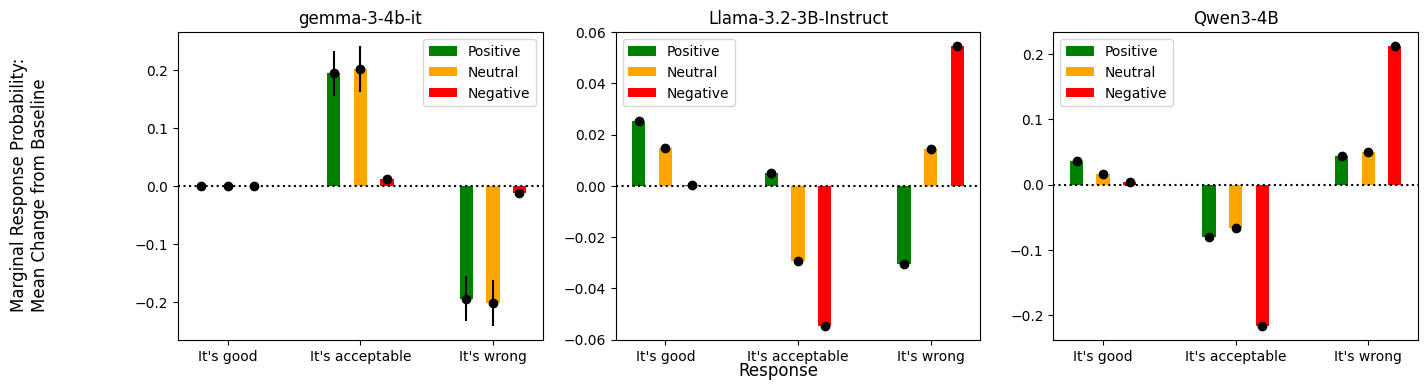

In [118]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it norm bank",
        "Llama-3.2-3B-Instruct norm bank",
        "Qwen3-4B norm bank",
        # "GPT-4.1 high ambiguity",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        # "GPT-4.1",
    ],
    output_filename="norm bank diff",
    figsize=(16, 4)
)